In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import os

# Check what's in risk_dashboard
print(os.listdir("../"))

['dashboard', 'data', 'models', 'notebooks', 'reports', 'requirements.txt.txt']


In [3]:
print(os.listdir("../data/"))

['processed', 'raw', 'risk_data.db']


In [4]:
print(os.listdir("../data/processed/"))

['returns_clean.csv']


In [5]:
returns = pd.read_csv("../data/processed/returns_clean.csv", 
                       index_col="Date", parse_dates=True)
print("Returns shape:", returns.shape)
returns.head()

Returns shape: (752, 15)


,AAPL,CVX,EL,GS,HLI,JNJ,JPM,KO,MCD,META,MRK,PLTR,ULTA,UNH,XOM
Date,,,,,,,,,,,,,,,
2022-01-04,-0.012773,0.018032,0.004231,0.030271,0.044539,-0.002685,0.037209,0.016557,-0.000261,-0.005955,0.001819,-0.019619,0.013246,-0.022917,0.036924
2022-01-05,-0.026960,0.006485,-0.043278,-0.021958,-0.040624,0.006642,-0.018451,0.008259,-0.004928,-0.037419,0.023992,-0.068914,-0.042068,-0.002468,0.012361
2022-01-06,-0.016834,0.008473,-0.002024,-0.004274,0.048372,-0.003432,0.010568,-0.005278,0.009313,0.025251,-0.000634,-0.013057,-0.002494,-0.041785,0.023248
2022-01-07,0.000988,0.014258,-0.001295,0.001460,0.010838,0.013427,0.009860,-0.002318,-0.009800,-0.002017,0.018476,-0.010811,-0.008501,-0.023810,0.008163
2022-01-10,0.000116,0.000640,-0.055137,0.004167,0.036082,-0.004956,0.000957,0.001656,-0.009973,-0.011275,0.025452,-0.003630,-0.041284,0.013859,-0.005970


In [6]:
import os
print(os.path.abspath("../data/processed/returns_clean.csv"))

C:\Users\user\Desktop\risk_dashboard\data\processed\returns_clean.csv


In [7]:
import os
print(os.path.exists("../data/processed/returns_clean.csv"))

True


In [8]:
def historical_var(returns, confidence=0.95):
    var_results = {}
    for ticker in returns.columns:
        r = returns[ticker].dropna()
        var = np.percentile(r, (1 - confidence) * 100)
        var_results[ticker] = round(var, 4)
    return var_results

In [9]:
var_95 = historical_var(returns, confidence=0.95)
var_99 = historical_var(returns, confidence=0.99)

var_df = pd.DataFrame({
    "VaR_95%": var_95,
    "VaR_99%": var_99
})
print(var_df)

      VaR_95%  VaR_99%
AAPL  -0.0276  -0.0456
CVX   -0.0261  -0.0469
EL    -0.0376  -0.0631
GS    -0.0241  -0.0433
HLI   -0.0263  -0.0405
JNJ   -0.0160  -0.0256
JPM   -0.0251  -0.0438
KO    -0.0153  -0.0251
MCD   -0.0169  -0.0299
META  -0.0421  -0.0702
MRK   -0.0187  -0.0302
PLTR  -0.0635  -0.0871
ULTA  -0.0325  -0.0472
UNH   -0.0242  -0.0435
XOM   -0.0280  -0.0444


In [10]:
var_df.to_csv("../data/processed/historical_var.csv")
print("Saved!")

Saved!


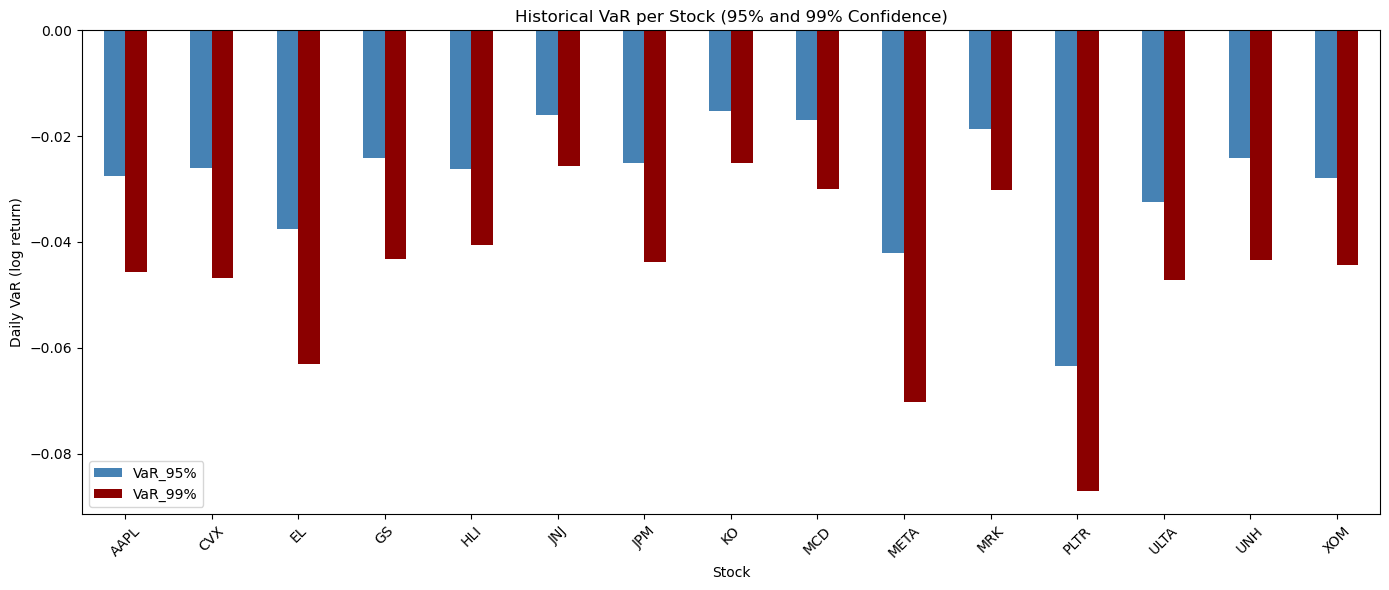

In [11]:
var_df[["VaR_95%", "VaR_99%"]].plot(
    kind="bar", 
    figsize=(14, 6),
    color=["steelblue", "darkred"],
    title="Historical VaR per Stock (95% and 99% Confidence)"
)
plt.ylabel("Daily VaR (log return)")
plt.xlabel("Stock")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../reports/historical_var_chart.png")
plt.show()

In [12]:
# Summary interpretation
summary = pd.DataFrame({
    "VaR_95%": var_95,
    "VaR_99%": var_99
})

# Add risk level column
def risk_level(var):
    if var < -0.05:
        return "🔴 Very High Risk"
    elif var < -0.03:
        return "🟠 High Risk"
    elif var < -0.02:
        return "🟡 Medium Risk"
    else:
        return "🟢 Low Risk"

summary["Risk Level"] = summary["VaR_95%"].apply(risk_level)
summary["Max Loss 95% (%)"] = (summary["VaR_95%"] * 100).round(2).astype(str) + "%"
summary["Max Loss 99% (%)"] = (summary["VaR_99%"] * 100).round(2).astype(str) + "%"

# Sort by riskiest
summary = summary.sort_values("VaR_95%")

print("=" * 60)
print("   HISTORICAL VAR RESULTS - RISK RANKING")
print("=" * 60)
print(summary[["Max Loss 95% (%)", "Max Loss 99% (%)", "Risk Level"]])
print("=" * 60)
print(f"Most Risky Stock:  {summary.index[0]}  {summary['Max Loss 95% (%)'].iloc[0]}")
print(f"Safest Stock:      {summary.index[-1]}  {summary['Max Loss 95% (%)'].iloc[-1]}")

   HISTORICAL VAR RESULTS - RISK RANKING
     Max Loss 95% (%) Max Loss 99% (%)        Risk Level
PLTR           -6.35%           -8.71%  🔴 Very High Risk
META           -4.21%           -7.02%       🟠 High Risk
EL             -3.76%           -6.31%       🟠 High Risk
ULTA           -3.25%           -4.72%       🟠 High Risk
XOM             -2.8%           -4.44%     🟡 Medium Risk
AAPL           -2.76%           -4.56%     🟡 Medium Risk
HLI            -2.63%           -4.05%     🟡 Medium Risk
CVX            -2.61%           -4.69%     🟡 Medium Risk
JPM            -2.51%           -4.38%     🟡 Medium Risk
UNH            -2.42%           -4.35%     🟡 Medium Risk
GS             -2.41%           -4.33%     🟡 Medium Risk
MRK            -1.87%           -3.02%        🟢 Low Risk
MCD            -1.69%           -2.99%        🟢 Low Risk
JNJ             -1.6%           -2.56%        🟢 Low Risk
KO             -1.53%           -2.51%        🟢 Low Risk
Most Risky Stock:  PLTR  -6.35%
Safest Stock:  